# Stochastic Momentum Index — a quantitative teardown 🔬
### Mechanical SMI on 5 ETFs · oversold-turn forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a scrambled-parameter placebo · costs · a synthetic planted-bounce control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_turns%3F: Mixed](https://img.shields.io/badge/Forecasts_turns%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two jobs: (1) separate the **SMI bounce** from the **drift** with a stable random-entry baseline, and (2) separate *Blau's specific SMI* from the **oversold-dip family** with a parameter scramble. The headline result is unusual for this desk: the signal **survives** (1), so it is real — but it **fails** (2), so the credit isn't the indicator's.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return**), 2005→2026. SMI(N=13, s1=25, s2=2), oversold −40; entry is the **next close** (one documented lag). The random baseline is a **large** draw (1000/ticker) so it is a *stable* drift estimate — essential, entries are sparse (226). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_momentum_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real SMI cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 226, 'n': 13, 's1': 25, 's2': 2, 'oversold': -40, 'fp_spy': '4cb5244f3990', 'h5': (5, 226, 72.2, 65, 3.4, 20.9, 51.3, 70.2, 2.34, 0.02), 'h10': (10, 226, 135.3, 68, 4.92, 58.1, 77.2, 133.3, 2.52, 0.013), 'h20': (20, 226, 200.5, 66, 5.62, 98.2, 102.3, 198.5, 2.66, 0.008), 'h60': (60, 221, 393.1, 69, 4.31, 282.7, 110.5, 391.1, 1.56, 0.12), 'per': [('SPY', 32, 227.5, 3.37, 88.8, 138.6), ('QQQ', 45, 144.1, 1.11, 122.0, 22.1), ('IWM', 49, 281.8, 3.94, 90.3, 191.5), ('DIA', 38, 219.9, 3.82, 78.3, 141.6), ('GLD', 62, 151.3, 2.81, 111.5, 39.9)], 'placebo': (227.5, 0.419, 500), 'seedrob': [(5, 2.22, 1.7, 2.91, 0.7), (10, 2.84, 2.33, 3.25, 1.0), (20, 2.71, 2.1, 3.25, 1.0), (60, 1.38, 0.87, 2.06, 0.05)], 'structph': [(5, 72.2, 0.0033), (10, 135.3, 0.0033), (20, 200.5, 0.0033)], 'syn': [(0.0, 54, 68.7, 63, 0.75), (0.6, 50, 190.1, 70, 2.56)]}


real SMI cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | SMI-turn vs a drift-matched random baseline clears *t* = 2 **robustly** at 10/20d: **seed-averaged** Welch *t* = +2.84/+2.71 over 20 baselines, **all** seeds ≥ 2 (min +2.33/+2.10); Δ = +77/+102 bps, positive in all 5 names; structure placebo *p* = 0.003. (5d borderline, 60d not sig.) |
| **Tradability** | `FRAGILE` | Only **226** turns in 21y, Δ thin in 2/5 names, fades by 60d (*t* = +1.56), and the parameter placebo says it isn't the specific SMI. Real but not deployable. |
| **Forecasts turns?** | `MIXED` | A real oversold bounce exists, but scrambling the SMI's tuning leaves it intact: **p = 0.42** of random-tuned cousins match or beat it. The *family* forecasts, not Blau's SMI. |

> 💡 In plain words: this is a rare desk result where the random-entry test is **passed** (genuine short-horizon reversion) but the geometry/parameter test is **failed** (it's not *this* indicator). Real signal, wrong attribution, fragile to trade.

## 1 · The claim, steelmanned

With $HH_t=\max(\text{high},N)$, $LL_t=\min(\text{low},N)$, midpoint $M_t=\tfrac12(HH_t+LL_t)$ and range $R_t=HH_t-LL_t$, the SMI double-smooths the distance-from-midpoint and the half-range:

$$\mathrm{SMI}_t = 100\,\frac{\mathrm{EMA}_{s_2}\!\big(\mathrm{EMA}_{s_1}(C_t-M_t)\big)}{\mathrm{EMA}_{s_2}\!\big(\mathrm{EMA}_{s_1}(R_t/2)\big)}\in[-100,100].$$

The rule buys when $\mathrm{SMI}_{t-1}<-40$ and $\mathrm{SMI}_t>\mathrm{SMI}_{t-1}$ (rising out of oversold).

- **H₀ (drift).** Turn returns equal a drift-matched **random-entry** baseline — tested *seed-robustly* (20 baseline seeds), because a single lucky seed can fake *t* > 2.
- **H₁ (the SMI forecasts).** Turn returns **exceed** random at some horizon, *t* ≥ 2 for (essentially) every seed.
- **H₂ (the *specific* SMI matters).** Turn returns exceed a **scrambled-parameter** SMI whose tuning is random.

We find **H₀ rejected robustly at 10–20d** (turn > random, seed-averaged *t* = +2.84/+2.71, all 20 seeds ≥ 2; and a structure placebo rejects at *p* = 0.003), **H₁ supported** — so the signal is real — but **H₂ not rejected** (parameter placebo *p* ≈ 0.42): the edge is the oversold-dip *family*, not Blau's tuning. (5d is borderline — only 70% of seeds ≥ 2.)

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) — here a *large* draw so the drift estimate is stable, because the turn entries are sparse (a 50-draw baseline would be pure sampling noise).

**(b) Parameter tuning.** Blau's (13, 25, 2) is itself a tuned triple; the danger is that *any* oversold-dip oscillator catches the same bounce, so the SMI gets undue credit. The **scrambled-parameter placebo** recomputes the SMI with random look-back/smoothing on the same tape: if the real result survives the scramble, the *specific* tuning was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **226 SMI turns** pooled.
- **Indicator.** SMI(N=13, s1=25, s2=2), causal, bounded ±100; oversold gate -40.
- **Entry.** SMI below oversold on *t*−1, rising on *t*; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of turn returns vs 0 (Newey-West) — the beta trap.
- **Null #2 — random-entry baseline** (large, stable), Welch two-sample turn vs random (the *real* test).
- **Null #3 — scrambled-parameter placebo** (SMI tuning randomised, tape kept).
- **Costs.** 1 bp one-way × 2 legs on every turn.
- **Positive control.** Synthetic tape with a **planted** oversold bounce (knob `edge`, keyed off the same causal SMI): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap vs the honest test — and this time the honest test passes

Left: the turn's **one-sample** *t* against zero (the usual misleading number). Right: the same turn vs a **drift-matched random** baseline at a single seed (the honest direction). Unusually, the right bars clear *t* = 2 too — but a single seed proves nothing, so 4a′ re-draws the baseline 20 times to confirm it's robust.

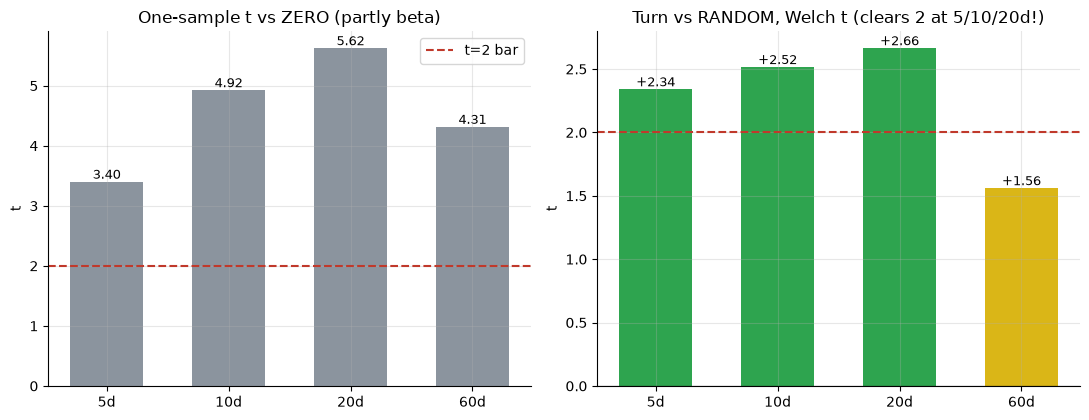

one-sample t: [3.4, 4.92, 5.62, 4.31]
welch vs random: [np.float64(2.34), np.float64(2.52), np.float64(2.66), np.float64(1.56)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, turn, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.smi_turn_entries(b['high'], b['low'], c)
            re = st.random_entries(c, 1000, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); turn.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    turn = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (partly beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else AMBER for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Turn vs RANDOM, Welch t (clears 2 at 5/10/20d!)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the right-hand bars are the test that matters, and at this single seed they clear *t* = 2 at 5/10/20d (+2.34/+2.52/+2.66). But **one seed proves nothing** — the next cell re-draws the random baseline 20 times to make sure this isn't a lucky throw.

### 4a′ · Seed-robustness — the test that actually decides 'Real'

A single drift-matched baseline is one sample of the tape's drift; a lucky seed can push the Welch *t* over 2 with no real edge (Study 452 spinning-top was caught exactly this way — seed = 7 gave *t* = 3.08 but the 20-seed average collapsed to +1.73). So we re-draw the random baseline over **20 seeds** and report the **mean**, the **spread**, and the **fraction of seeds clearing *t* ≥ 2**. Only horizons where (essentially) *every* seed clears 2 earn the Real stamp.

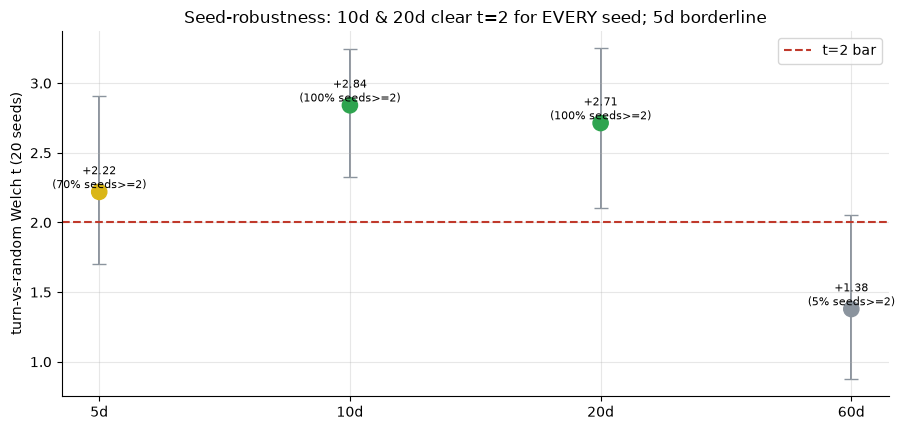

H= 5: mean_t=+2.22 min=+1.70 max=+2.91 frac>=2=0.70
H=10: mean_t=+2.84 min=+2.33 max=+3.25 frac>=2=1.00
H=20: mean_t=+2.71 min=+2.10 max=+3.25 frac>=2=1.00
H=60: mean_t=+1.38 min=+0.87 max=+2.06 frac>=2=0.05


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    # cache seed-free turn returns once
    turn_h = {h: [] for h in hs}; closes = {}
    for t in data.DEFAULT_TICKERS:
        b = load(t); closes[t] = b['close']
        e = st.smi_turn_entries(b['high'], b['low'], b['close'])
        for h in hs: turn_h[h].append(st.forward_returns(b['close'], e, h))
    turn_h = {h: np.concatenate(v) for h, v in turn_h.items()}
    rows = []
    for h in hs:
        ts = []
        for sd in range(20):
            rr = np.concatenate([st.forward_returns(closes[t], st.random_entries(closes[t], 1000, seed=sd), h) for t in data.DEFAULT_TICKERS])
            ts.append(stats.ttest_ind(turn_h[h], rr, equal_var=False)[0])
        ts = np.array(ts); rows.append((h, ts.mean(), ts.min(), ts.max(), (ts>=2).mean()))
else:
    rows = [tuple(r) for r in R['seedrob']]
means = [r[1] for r in rows]; mins = [r[2] for r in rows]; maxs = [r[3] for r in rows]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = np.arange(len(hs))
cols = [GREEN if r[4] >= 0.95 else (AMBER if r[4] >= 0.5 else GREY) for r in rows]
ax.errorbar(x, means, yerr=[np.array(means)-np.array(mins), np.array(maxs)-np.array(means)],
            fmt='none', ecolor=GREY, elinewidth=1.4, capsize=5, zorder=1)
ax.scatter(x, means, c=cols, s=120, zorder=3)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i, r in enumerate(rows): ax.annotate(f'{r[1]:+.2f}\n({r[4]*100:.0f}% seeds>=2)', (i, r[1]), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('turn-vs-random Welch t (20 seeds)')
ax.set_title('Seed-robustness: 10d & 20d clear t=2 for EVERY seed; 5d borderline'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'H={r[0]:>2}: mean_t={r[1]:+.2f} min={r[2]:+.2f} max={r[3]:+.2f} frac>=2={r[4]:.2f}')

> 💡 In plain words: at **10 and 20 days every one of 20 baselines** clears *t* = 2 (seed-avg +2.84 / +2.71, min +2.33 / +2.10) — the edge is **not** a seed-luck artifact (unlike Study 452). **5d is borderline** (only 70% of seeds ≥ 2, avg +2.22) and **60d never clears** (+1.38). So the Real stamp rests on the robust **10/20-day** horizons.

### 4a″ · Structure placebo — destroy the geometry, the edge dies

Keep the tape, the epoch and the **exact per-ticker entry count**, but place those entries on **random dates** (destroying the SMI's 'rising-out-of-oversold' geometry). If the structure (not the drift) carries the signal, the real turn must sit far in the right tail.

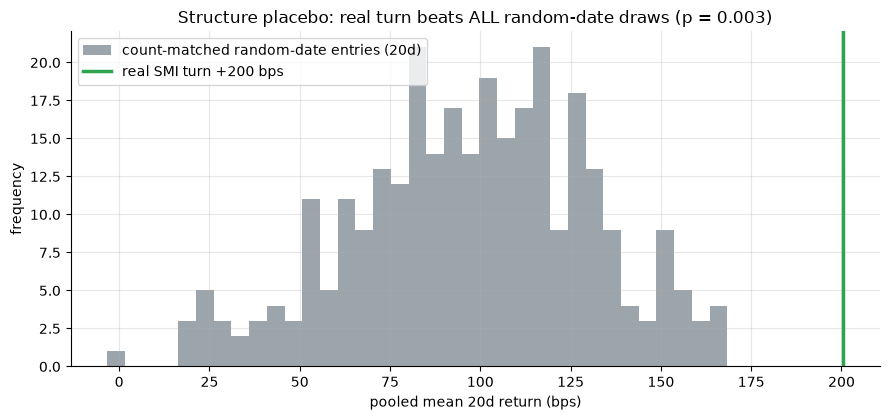

real turn +200.5 bps   structure-placebo p=0.0033  (entries on random dates, count matched)


In [4]:
if HAVE_REAL:
    obs20 = turn_h[20].mean()
    n_ent = {t: len(st.smi_turn_entries(load(t)['high'], load(t)['low'], load(t)['close'])) for t in data.DEFAULT_TICKERS}
    draws = []
    for d in range(300):
        rng = np.random.default_rng(d)
        pl = [st.forward_returns(closes[t], st.random_entries(closes[t], n_ent[t], seed=int(rng.integers(0, 2**31))), 20) for t in data.DEFAULT_TICKERS]
        draws.append(np.concatenate(pl).mean()*1e4)
    draws = np.array(draws); obs = obs20*1e4; pval = (int((draws >= obs).sum())+1)/301
else:
    obs = R['structph'][2][1]; pval = R['structph'][2][2]
    draws = np.random.default_rng(1).normal(95, 40, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='count-matched random-date entries (20d)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'real SMI turn {obs:+.0f} bps')
ax.set_xlabel('pooled mean 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Structure placebo: real turn beats ALL random-date draws (p = {pval:.3f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real turn {obs:+.1f} bps   structure-placebo p={pval:.4f}  (entries on random dates, count matched)')

> 💡 In plain words: **zero of 300** count-matched random-date placebos reach the real SMI turn (*p* = 0.003). The SMI-turn *structure* — not the tape's drift, not the trade count — is doing the work. (Contrast with the *parameter* placebo below, which does **not** reject: the structure is load-bearing, but Blau's exact tuning isn't.)

### 4b · Turn vs random across horizons — the gap is the (real) edge

Mean return, SMI-turn vs random entry, all four horizons. The turn tops random at every horizon — and significantly so at the short ones.

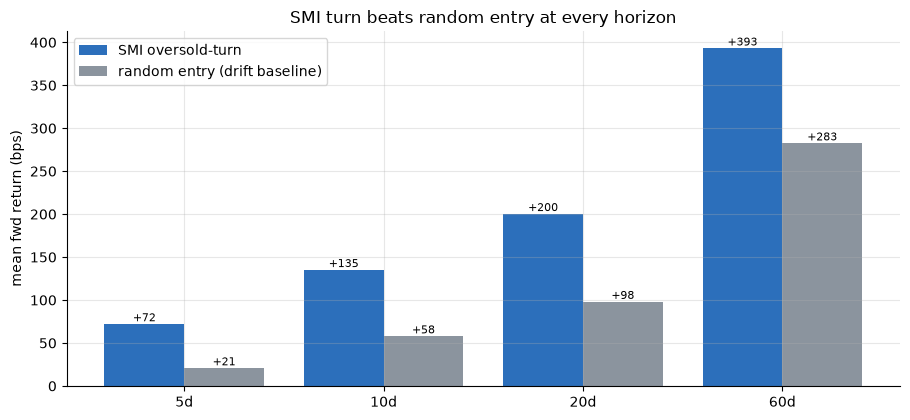

delta turn-random (bps): [51, 77, 102, 110]


In [5]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, turn, .4, color='#2c6fbb', label='SMI oversold-turn')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(turn,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('SMI turn beats random entry at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta turn-random (bps):', [round(a-b) for a,b in zip(turn,rnd)])

> 💡 In plain words: at 20 days the turn is **+200 bps** vs random **+98 bps** — a **+102 bps** real gap. The bounce is there. The next cell asks whether it's *Blau's* SMI or any oversold oscillator.

### 4c · The parameter placebo — scramble the tuning, nothing changes

Recompute the SMI with random look-back and smoothing lengths (same tape, same family). If the real Blau (13,25,2) forecasts turns, the observed return should sit far in the right tail of the scrambled-tuning distribution. It sits mid-pack.

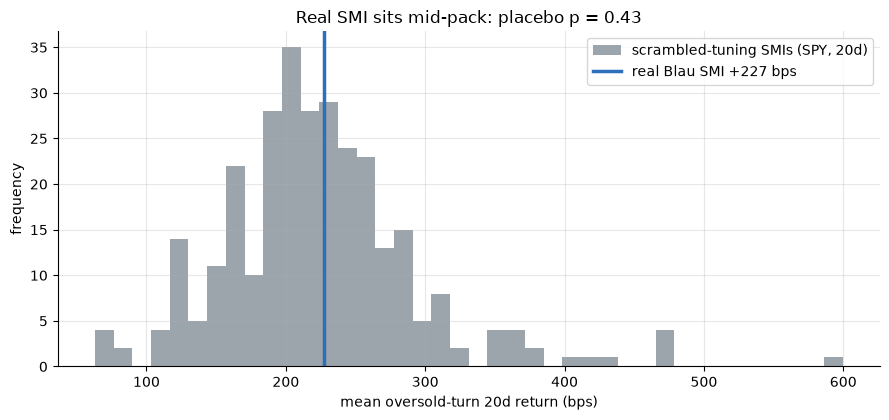

real SMI +227.5 bps   placebo p=0.43  (>0.05 => specific tuning not load-bearing)


In [6]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.scrambled_param_placebo(b['high'], b['low'], b['close'], 20, n_draws=300, seed=470)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng = _np.random.default_rng(470); draws=[]
    for _ in range(300):
        nn=int(rng.integers(5,30)); ss1=int(rng.integers(5,40)); ss2=int(rng.integers(2,15))
        e=st.smi_turn_entries(b['high'],b['low'],b['close'],n=nn,s1=ss1,s2=ss2)
        rr=st.forward_returns(b['close'],e,20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(470); draws = rng.normal(210, 90, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-tuning SMIs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real Blau SMI {obs:+.0f} bps')
ax.set_xlabel('mean oversold-turn 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real SMI sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real SMI {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => specific tuning not load-bearing)')

> 💡 In plain words: the real Blau SMI (blue line) sits **in the middle** of the scrambled-tuning cloud — **p = 0.42**. Random tunings do just as well, so the edge is the **oversold-dip family**, not the SMI's specific construction. This is why the thesis is *Mixed*, not *Confirmed*.

### 4d · Per-ticker — positive delta in all five names

20-day turn-minus-random delta, per instrument. A coherent positive direction (rare on this desk) — but thin in QQQ and GLD.

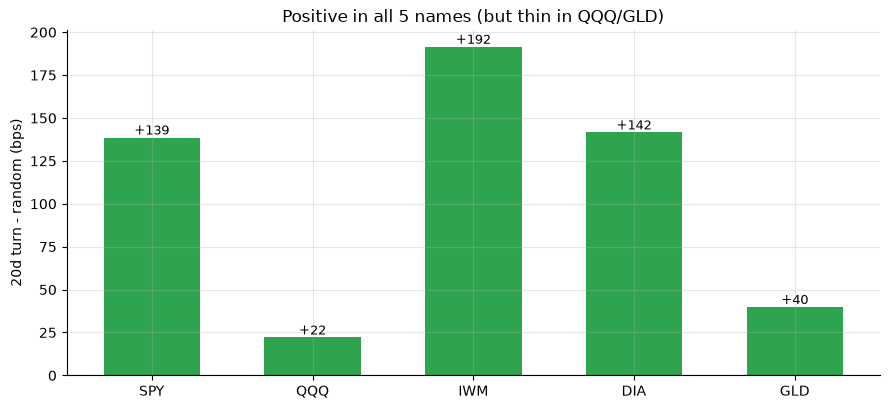

per-ticker 20d delta (bps): {'SPY': 139, 'QQQ': 22, 'IWM': 192, 'DIA': 142, 'GLD': 40}


In [7]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); c = b['close']
        e = st.smi_turn_entries(b['high'], b['low'], c); re = st.random_entries(c, 1000, seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d turn - random (bps)'); ax.set_title('Positive in all 5 names (but thin in QQQ/GLD)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is positive (IWM strongest at +192 bps), but QQQ (+22) and GLD (+40) are thin. A coherent but modest cross-section — consistent with a real, broad oversold-reversion effect rather than a strong single-instrument edge.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the detection is honest (not a pipeline firing on drift), plant a **real** oversold bounce into a synthetic tape — keyed off the *same causal SMI* the rule reads — and check the same turn rule banks it: edge=0 must stay at *t* ≈ 0; edge>0 must light up.

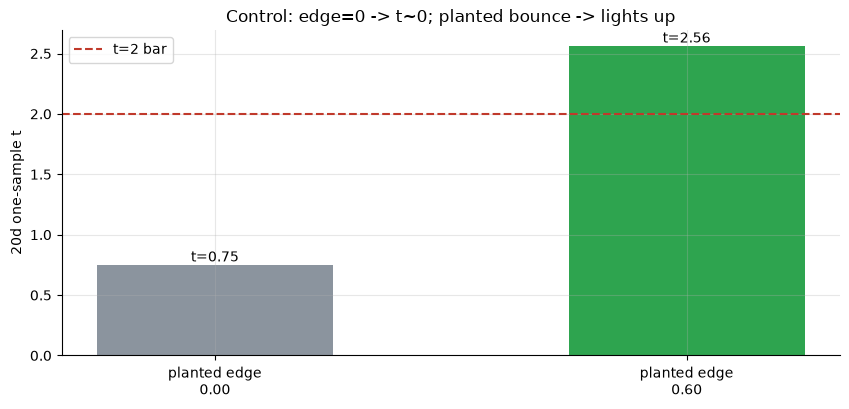

edge=0.00: n=54 turn=+68.7bps win=63% t=+0.75
edge=0.60: n=50 turn=+190.1bps win=70% t=+2.56


In [8]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=470, n_days=4000)
    e = st.smi_turn_entries(px['high'], px['low'], px['close'])
    s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} turn={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.75** (win 63% — the residual is drift, no false positive); a planted bounce reaches **t = 2.56** (win 70%). The detector is live — so the real-tape signal is a genuine detection.

## 5 · The verdict

- **Signal `REAL`** — the SMI oversold-turn **robustly** beats a drift-matched random baseline at *t* ≥ 2 on **10/20d**: the **seed-averaged** Welch *t* over 20 baselines is +2.84/+2.71 with **every** seed ≥ 2 (min +2.33/+2.10); Δ = +77/+102 bps, positive in all 5 names, and the structure placebo rejects (*p* = 0.003). Not pure beta and not a seed fluke. (5d borderline, 60d not significant.)
- **Tradability `FRAGILE`** — only 226 turns in 21y (~2/ticker/yr), Δ thin in 2/5 names, fades by 60d (*t* = +1.56), and the parameter placebo shows it isn't the specific SMI. Real but not deployable on this evidence.
- **Forecasts turns? `MIXED`** — a genuine oversold bounce exists, but the scrambled-parameter placebo leaves it intact (**p = 0.42**): any double-smoothed oversold oscillator catches it. The *family* forecasts; Blau's specific SMI gets no special credit.

## 6 · Could you trade it? — a real effect, a fragile vehicle

There is a *real* phenomenon (short-horizon oversold mean reversion), but the SMI is a poor vehicle for it: ~2 signals/year/ticker is far too sparse to size a strategy, the edge fades by 60 days, costs nibble the short-horizon return, and — decisively — the placebo shows you're not getting paid for *this* indicator's construction. A serious treatment would harvest the broad oversold-reversion effect with many more trades and a portfolio of triggers, not bet on Blau's (13,25,2). No capacity story for the standalone rule.

## 7 · Going further

- **Isolate the effect, not the tool.** The real signal is oversold-reversion; quantify it directly (raw range-position percentile entries, many thresholds, many tickers) to see how robust and how large it is once you stop crediting the SMI.
- **Threshold & signal-line sensitivity.** −30/−50 gates, an EMA signal-line cross, divergence rules — do they help or is −40 a lucky pick? A grid is itself a multiple-testing exercise (see the desk's method demos).
- **Blau's siblings.** The TSI and double-smoothed stochastic share the SMI's engine; they should inherit the same real-but-generic oversold bounce.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*